# Plane Wing Oscillations
#### Saran Kaba (sk65556)

### The average flight experiences 30 minutes of turbulence which is factored into the creation of planes, specifically their wings(Chuinkam, 2026). To counteract the effects of turbulence, the wings are designed to be flexible and bend when experiencing stress. This causes oscillations

### For studies that do add structural damping, the industry standard applied tonthe Goland model is ζ = 1–2% (0.01–0.02) of critical damping per mode, consistent with metallic aircraft structures. zeta is damping ration not coefficient

$\frac{d^2y}{dt^2} = f(t, y, \frac{dy}{dt})$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Define the parameters
k = 9772200.0        # Spring constant/bending stiffness
h = [.0001, .00018, .0006,.0009]       # Step size
x_start = 0.0   # Start of the interval
x_end = .1    # End of the interval
y_0 = 0.01    # Initial condition for y
v_0 = 0.0     # Initial condition for dy/dx
m=217.7       # Mass of the wing (kg)
c= 0.0        # Damping coefficient

def analytical_solution(x):
    return np.exp(-4.238*x)*(0.01*np.cos(211.88*x)+0.0002*np.sin(211.88*x))

## Euler's Forward

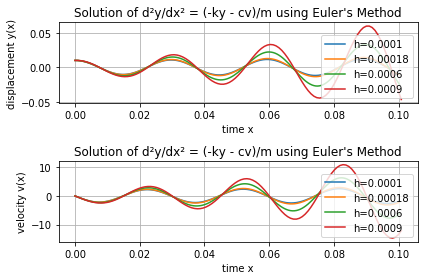

In [2]:
fig,(one,two)=plt.subplots(2,1)

euler_error=[]

def eulers(x_start,x_end,k,h,y_0,v_0,m,c):
    # Create arrays to store x, y, v, and error values
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))
    error=[]
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    # Euler's Method loop
    for i in range(1, len(x_values)):
        # Current values
        x_n = x_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]    
        # Update equations
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n-c*v_n)/m
        
        an_solution=analytical_solution(x_values[i])
        error.append(np.abs(an_solution-y_values[i]))
    return x_values,y_values,v_values,error

eu_error=[]
for j in h:
    x_values,y_values,v_values,eerror=eulers(x_start,x_end,k,j,y_0,v_0,m,c)
    eu_error.append(np.mean(eerror))
   # Plot the results
    one.plot(x_values, y_values, label=f'h={j}')
    two.plot(x_values, v_values, label=f'h={j}')
one.set_xlabel('time x')
two.set_xlabel('time x')
one.set_ylabel('displacement y(x)')
two.set_ylabel('velocity v(x)')
one.set_title('Solution of d²y/dx² = (-ky - cv)/m using Euler\'s Method')
two.set_title('Solution of d²y/dx² = (-ky - cv)/m using Euler\'s Method')
one.legend()
two.legend()
one.grid(True)
two.grid(True)
plt.tight_layout()
plt.show()

## Fourth-Order Runge-Kutta (RK4) 

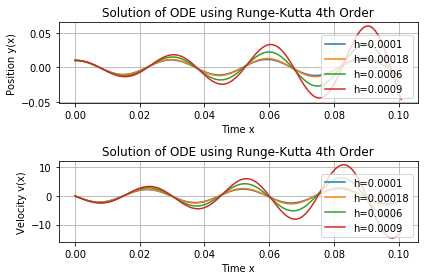

In [3]:
# Define the function
def f(c,vr,k,yr):
    return (-c*vr-k*yr)/m
# Implement the RK4 method
def runge_kutta_4(f, y0, x0, xf, h,v0):
    # Create an array for time steps
    x_values = np.arange(x0, xf + h, h)
    y_values = np.zeros(len(x_values)) 
    v_values=np.zeros(len(x_values))
    error=[]
    # Set the initial condition
    y_values[0] = y0
    v_values[0]=v0
    # Perform the RK4 iteration
    for i in range(1, len(x_values)):
        y = y_values[i - 1]
        v = v_values[i - 1]        
        k1 = h*v
        r1=h * f(c,v,k,y)
        k2 = h * (v+h/2*r1)
        r2=h * f(c,v+h/2*r1,k,y+h/2*k1)
        k3 =h*(v+h/2*r2)
        r3=h * f(c,v+h/2*r2,k,y+h/2*k2)
        k4 =h*(v+h*r3)
        r4=h * f(c,v+h*r3,k,y+h*k3)
        # Update y based on the RK4 formula
        y_values[i] = y + (k1 + 2 * k2 + 2 * k3 + k4) / 6
        v_values[i]=v+(r1+2*r2+2*r3+r4)/6
        
        #Calculate error
        an_solution=analytical_solution(x_values[i])
        error.append(np.abs(an_solution-y_values[i]))
        
    return x_values,y_values, v_values,error

fig,(oner,twor)=plt.subplots(2,1)

rk_error=[]
for j in h:
    # Run the RK4 solver
    xr_values,yr_values, vr_values,rerror = runge_kutta_4(f, y_0, x_start, x_end, j,v_0)
    
    #calculate error
    rk_error.append(np.mean(rerror))
    
    # Plot the results
    oner.plot(xr_values, yr_values, label=f'h={j}')
    twor.plot(xr_values, vr_values, label=f'h={j}')
oner.set_xlabel('Time x')
oner.set_ylabel('Position y(x)')
oner.set_title('Solution of ODE using Runge-Kutta 4th Order')
oner.legend()
oner.grid(True)

twor.set_xlabel('Time x')
twor.set_ylabel('Velocity v(x)')
twor.set_title('Solution of ODE using Runge-Kutta 4th Order')
twor.legend()
twor.grid(True)

plt.tight_layout()
plt.show()

## Stability Analysis

### The maximum step size for stability for Euler's forward method is 0.00018, while the maximum step size for Runge-Kutta is 0.01264. Below the stability is being checked for the different values of h used. Note the final two values surpass the maximim step size for Euler's.

In [4]:
print('Stability for Euler\'s Forward:')
def stabilitycheckereuler(h,k,m,c):
    A=np.array([[1,h],[-k*h/m,1-c*h/m]])
    eigVa,eigVe=np.linalg.eig(A)
    if np.all(np.abs(eigVa)<=1):
        re="Solution is Stable"
    else:
        re="Solution is Unstable"
    return re

for j in h:
    print(f"for h= {j} the {stabilitycheckereuler(j,k,m,c)}")
print('Stability for Runge-Kutta:')
def rk4_stability_function(h,k,m,c):
    A=[[0,1],[-k/m,-c/m]]
    eigVa,eigVe=np.linalg.eig(A)
    
    re="Solution is Stable"
    for j in eigVa:
        z=h*j
        rz = 1 + z + (z**2) / 2 + (z**3) / 6 + (z**4) / 24
        if np.abs(rz)>1:
            re="Solution is Unstable"
            break
    return re
    
for j in h:
    print(f'For h = {j} the {rk4_stability_function(j,k,m,c)}')

Stability for Euler's Forward:
for h= 0.0001 the Solution is Unstable
for h= 0.00018 the Solution is Unstable
for h= 0.0006 the Solution is Unstable
for h= 0.0009 the Solution is Unstable
Stability for Runge-Kutta:
For h = 0.0001 the Solution is Stable
For h = 0.00018 the Solution is Stable
For h = 0.0006 the Solution is Stable
For h = 0.0009 the Solution is Stable


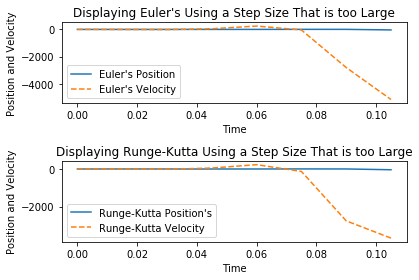

In [5]:
hm=0.015
xem,yem,vem,er=eulers(x_start,x_end,k,hm,y_0,v_0,m,c)
xrm,yrm, vrm,er = runge_kutta_4(f, y_0, x_start, x_end, hm ,v_0)

plt.subplot(2,1,1)
plt.plot(xem,yem,label='Euler\'s Position')
plt.plot(xem,vem,label='Euler\'s Velocity',linestyle='--')
plt.xlabel('Time')
plt.ylabel('Position and Velocity')
plt.title('Displaying Euler\'s Using a Step Size That is too Large')
plt.legend()

plt.subplot(2,1,2)
plt.plot(xrm,yrm,label='Runge-Kutta Position\'s')
plt.plot(xrm,vrm,label='Runge-Kutta Velocity',linestyle='--')
plt.title('Displaying Runge-Kutta Using a Step Size That is too Large')
plt.xlabel('Time')
plt.ylabel('Position and Velocity')
plt.legend()

plt.tight_layout()
plt.show()

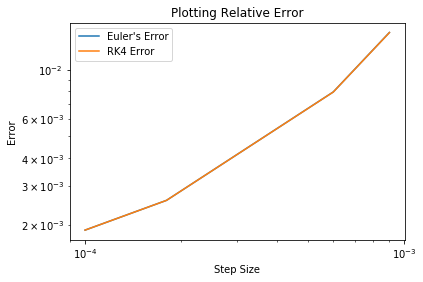

In [6]:
plt.figure()
plt.plot(h,eu_error,label='Euler\'s Error')
plt.plot(h,rk_error,label='RK4 Error')
plt.title('Plotting Relative Error')
plt.xlabel('Step Size')
plt.ylabel('Error')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.show()